## STUDENT INFO: 
### 1) Name : TAN ZHI MING , JOANNE CHENG JING XUAN , LIM YU HAN
### 2) Matric No : A23CS0189 , A23CS0227 , A23CS0241
### 3) Section : 02

# 🧾 Retail Sales Analysis with Pandas DataFrames & MultiIndexing
**Total Marks:** 30

**Objective:** Provide solutions for DataFrame manipulation, aggregation, filtering, and MultiIndexing.

### Question 1: Create and Explore Sales DataFrame (5 marks)

1.1 Create a DataFrame containing at least 8 rows with the following columns:
```Region, City, Category, Units Sold, Unit Price, Month```.

##### SAMPLE DATAFRAME:
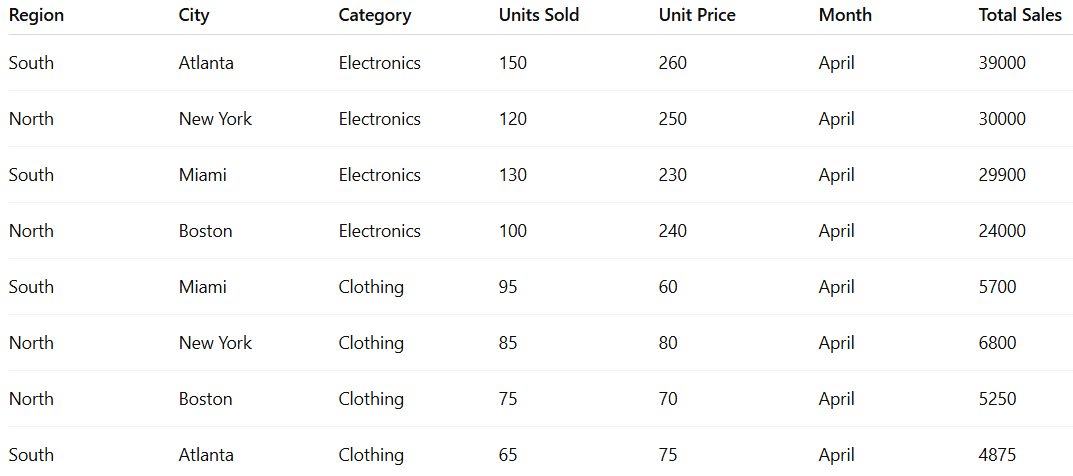

Use at least 2 regions (e.g., North, South), 2 cities per region, and 2 product categories (e.g., Electronics, Clothing). 
                                                                                                              (2 marks)

1.2 Add a column ```"Total Sales"``` = Units Sold × Unit Price. (1 mark)

1.3 Sort the DataFrame by ```"Total Sales"``` in descending order. (2 marks)

In [80]:
import pandas as pd

# 1.1

data = {'Region': ['South', 'North'] *3 + ['North', 'South'],
        'City': ['Atlanta', 'New York', 'Miami', 'Boston', 'Miami', 'New York', 'Boston', 'Atlanta'],
        'Category': ['Electronic'] *4 + ['Clothing'] *4,
        'Units Sold': [150, 120, 130, 100, 95, 85, 75, 65],
        'Unit Price': [260, 250, 230, 240, 60, 80, 70, 75],
        'Month': ['April'] *8
       }

df = pd.DataFrame(data)
df

,Region,City,Category,Units Sold,Unit Price,Month
0,South,Atlanta,Electronic,150,260,April
1,North,New York,Electronic,120,250,April
2,South,Miami,Electronic,130,230,April
3,North,Boston,Electronic,100,240,April
4,South,Miami,Clothing,95,60,April
5,North,New York,Clothing,85,80,April
6,North,Boston,Clothing,75,70,April
7,South,Atlanta,Clothing,65,75,April


In [82]:
# 1.2

df['Total Sales'] = df['Units Sold'] * df['Unit Price']
df

,Region,City,Category,Units Sold,Unit Price,Month,Total Sales
0,South,Atlanta,Electronic,150,260,April,39000
1,North,New York,Electronic,120,250,April,30000
2,South,Miami,Electronic,130,230,April,29900
3,North,Boston,Electronic,100,240,April,24000
4,South,Miami,Clothing,95,60,April,5700
5,North,New York,Clothing,85,80,April,6800
6,North,Boston,Clothing,75,70,April,5250
7,South,Atlanta,Clothing,65,75,April,4875


In [84]:
# 1.3

df_sorted = df.sort_values(by='Total Sales', ascending=False)
df_sorted

,Region,City,Category,Units Sold,Unit Price,Month,Total Sales
0,South,Atlanta,Electronic,150,260,April,39000
1,North,New York,Electronic,120,250,April,30000
2,South,Miami,Electronic,130,230,April,29900
3,North,Boston,Electronic,100,240,April,24000
5,North,New York,Clothing,85,80,April,6800
4,South,Miami,Clothing,95,60,April,5700
6,North,Boston,Clothing,75,70,April,5250
7,South,Atlanta,Clothing,65,75,April,4875


### Question 2: MultiIndexing (7 marks)

2.1 Set a MultiIndex on Region, City, and Category. Display the resulting structure. (2 marks)

2.2 Retrieve all records for "South" region and "Clothing" category. (2 marks)

2.3 Use .xs() or slicing to get sales for a specific "City" regardless of region. (1 mark)

2.4 Reset the index and show the flat DataFrame. (2 marks)


In [87]:
# 2.1

df_multi = df.set_index(['Region', 'City', 'Category'])
df_multi

Units Sold  Unit Price  Month  Total Sales
Region City     Category                                              
South  Atlanta  Electronic         150         260  April        39000
North  New York Electronic         120         250  April        30000
South  Miami    Electronic         130         230  April        29900
North  Boston   Electronic         100         240  April        24000
South  Miami    Clothing            95          60  April         5700
North  New York Clothing            85          80  April         6800
       Boston   Clothing            75          70  April         5250
South  Atlanta  Clothing            65          75  April         4875

In [89]:
# 2.2

south_clothing = df_multi.loc[pd.IndexSlice["South", :, "Clothing"]]
south_clothing

,Units Sold,Unit Price,Month,Total Sales
City,,,,
Miami,95,60,April,5700
Atlanta,65,75,April,4875


In [91]:
# 2.3

atlanta_sales = df_multi.xs('Atlanta', level='City')
atlanta_sales

Units Sold  Unit Price  Month  Total Sales
Region Category                                              
South  Electronic         150         260  April        39000
       Clothing            65          75  April         4875

In [93]:
# 2.4

df_reset = df_multi.reset_index()
df_reset

,Region,City,Category,Units Sold,Unit Price,Month,Total Sales
0,South,Atlanta,Electronic,150,260,April,39000
1,North,New York,Electronic,120,250,April,30000
2,South,Miami,Electronic,130,230,April,29900
3,North,Boston,Electronic,100,240,April,24000
4,South,Miami,Clothing,95,60,April,5700
5,North,New York,Clothing,85,80,April,6800
6,North,Boston,Clothing,75,70,April,5250
7,South,Atlanta,Clothing,65,75,April,4875


### Question 3: Grouping and Aggregation (8 marks)
3.1 Use groupby() to calculate the total units sold per region. (2 marks)

3.2 Compute average unit price per product category. (2 marks)

3.3 Add a ```"Performance"``` column:

```"High"``` if ```Total Sales``` ≥ 10000

```"Medium"``` if 5000 ≤ ```Total Sales``` < 10000

```"Low"``` otherwise.
Use apply() or a vectorized method. (3 marks)

In [96]:
# 3.1

region_units = df.groupby('Region')['Units Sold'].sum()
region_units

Region
North    380
South    440
Name: Units Sold, dtype: int64

In [98]:
# 3.2

avg_price_category = df.groupby('Category')['Unit Price'].mean()
avg_price_category

Category
Clothing       71.25
Electronic    245.00
Name: Unit Price, dtype: float64

In [100]:
# 3.3

def label_performance(sales):
    if sales >= 10000:
        return "High"
    elif sales >= 5000:
        return "Medium"
    else:
        return "Low"

df['Performance'] = df['Total Sales'].apply(label_performance)
df

,Region,City,Category,Units Sold,Unit Price,Month,Total Sales,Performance
0,South,Atlanta,Electronic,150,260,April,39000,High
1,North,New York,Electronic,120,250,April,30000,High
2,South,Miami,Electronic,130,230,April,29900,High
3,North,Boston,Electronic,100,240,April,24000,High
4,South,Miami,Clothing,95,60,April,5700,Medium
5,North,New York,Clothing,85,80,April,6800,Medium
6,North,Boston,Clothing,75,70,April,5250,Medium
7,South,Atlanta,Clothing,65,75,April,4875,Low


### Question 4: Data Transformation (5 marks)
4.1 Normalize Units Sold and Total Sales using Min-Max scaling. (3 marks)

4.2 Save the normalized DataFrame to a CSV file called "normalized_sales.csv" (mock this). (2 marks)

In [103]:
# 4.1
def min_max_normalize(series):
    return (series - series.min()) / (series.max() - series.min())

# Create a copy to preserve original df
df_normalized = df.copy()

# Apply Min-Max scaling
df_normalized["Units Sold (Normalized)"] = min_max_normalize(df["Units Sold"])
df_normalized["Total Sales (Normalized)"] = min_max_normalize(df["Total Sales"])

# Display the updated DataFrame
print(df_normalized[["Units Sold", "Units Sold (Normalized)", 
                     "Total Sales", "Total Sales (Normalized)"]])

   Units Sold  Units Sold (Normalized)  Total Sales  Total Sales (Normalized)
0         150                 1.000000        39000                  1.000000
1         120                 0.647059        30000                  0.736264
2         130                 0.764706        29900                  0.733333
3         100                 0.411765        24000                  0.560440
4          95                 0.352941         5700                  0.024176
5          85                 0.235294         6800                  0.056410
6          75                 0.117647         5250                  0.010989
7          65                 0.000000         4875                  0.000000


In [105]:
# 4.2

df_normalized.to_csv('normalized_sales.csv', index=False)

### Question 5: Advanced Filtering (5 marks)
5.1 Filter the original DataFrame to show:

```"Electronics"``` category

Sold more than 100 units In the ```"North"``` region (3 marks)

5.2 From the MultiIndexed version, display all entries for a specific month (e.g., "April"). (2 marks)

In [108]:
# 5.1

filtered_df = df_sorted[(df_sorted['Category'] == 'Electronic') & 
                 (df_sorted['Region'] == 'North') & 
                 (df_sorted['Units Sold'] > 100)]
filtered_df

,Region,City,Category,Units Sold,Unit Price,Month,Total Sales
1,North,New York,Electronic,120,250,April,30000


In [110]:
# 5.2

april_data = df_multi[df_multi['Month'] == 'April']
april_data = april_data.reset_index()
april_data = april_data.ffill()
april_data

,Region,City,Category,Units Sold,Unit Price,Month,Total Sales
0,South,Atlanta,Electronic,150,260,April,39000
1,North,New York,Electronic,120,250,April,30000
2,South,Miami,Electronic,130,230,April,29900
3,North,Boston,Electronic,100,240,April,24000
4,South,Miami,Clothing,95,60,April,5700
5,North,New York,Clothing,85,80,April,6800
6,North,Boston,Clothing,75,70,April,5250
7,South,Atlanta,Clothing,65,75,April,4875
